In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

PATH = "C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/attainable_demand_baseline_p147_mar.csv"

df = pd.read_csv(PATH, encoding="utf-8-sig")
df["Дата"] = pd.to_datetime(df["Дата"])

print(df.shape)
df.head()

(2764, 31)


,Дата,Пекарня,Категория,Номенклатура,sku_sales_total,bakery_sales_total,good_execution_day,availability_score,stockout_like_hours,zero_under_traffic_hours,early_stop_flag,Продано,ДеньНедели,bakery_sales_total_calc,category_sales_total,share_of_bakery,share_of_category,final_expected_share,share_source_primary,blend_confidence_score,share_bakery_sku,share_sku_global,share_bakery_category,share_category_global,attainable_sales_from_bakery,attainable_sales_from_category,attainable_sales_baseline,attainable_gap,attainable_uplift_pct,opportunity_flag,opportunity_type
0,2026-03-17,Проспект Победы 147 Казань,Соки Морсы,Pulpy Ананас Манго,1.0,759.3,True,0.926667,1,4,False,1.0,1.0,759.3,14.0,0.001317,0.071429,0.109646,bakery_category,0.662091,0.001317,0.001317,0.119144,0.119144,83.254308,1.535046,1.535046,0.535046,53.504585,False,none
1,2026-03-31,Проспект Победы 147 Казань,Соки Морсы,Pulpy Ананас Манго,2.0,895.9,False,0.873333,3,5,False,2.0,1.0,895.9,30.0,0.002232,0.066667,0.109646,bakery_category,0.662091,0.001317,0.001317,0.119144,0.119144,98.231970,3.289384,3.289384,1.289384,64.469198,True,stockout_like
2,2026-03-13,Проспект Победы 147 Казань,Соки Морсы,Pulpy Апельсин,1.0,897.9,True,0.933333,2,2,False,1.0,4.0,897.9,8.0,0.001114,0.125000,0.107053,bakery_category,0.661254,0.001114,0.001114,0.115646,0.115646,96.122840,0.856424,1.000000,0.000000,0.000000,False,none
3,2026-03-14,Проспект Победы 147 Казань,Соки Морсы,Pulpy Апельсин,1.0,751.8,True,0.900000,2,4,False,1.0,5.0,751.8,6.0,0.001330,0.166667,0.106619,bakery_category,0.669267,0.001412,0.001412,0.120370,0.120370,80.155856,0.639712,1.000000,0.000000,0.000000,False,none
4,2026-03-18,Проспект Победы 147 Казань,Соки Морсы,Pulpy Апельсин,2.0,773.6,True,0.893333,2,5,False,2.0,2.0,773.6,13.0,0.002585,0.153846,0.105550,bakery_category,0.666809,0.001875,0.001875,0.117179,0.117179,81.653767,1.372155,2.000000,0.000000,0.000000,False,none


In [3]:
print("rows:", len(df))
print("rows_with_profiles:", df["final_expected_share"].notna().sum())
print("opportunity_rows:", df["opportunity_flag"].sum())
print("\nshare_source_primary")
print(df["share_source_primary"].value_counts(dropna=False))

print("\nopportunity_type")
print(df["opportunity_type"].value_counts(dropna=False))

print("\nattainable_gap describe")
print(df["attainable_gap"].describe())

rows: 2764
rows_with_profiles: 1647
opportunity_rows: 165

share_source_primary
share_source_primary
bakery_category    1631
NaN                1117
sku_global           16
Name: count, dtype: int64

opportunity_type
opportunity_type
none             2599
stockout_like     138
early_stop         27
Name: count, dtype: int64

attainable_gap describe
count    2764.000000
mean        2.275738
std        20.364616
min         0.000000
25%         0.000000
50%         0.000000
75%         0.097152
max       349.234357
Name: attainable_gap, dtype: float64


In [4]:
sku_summary = (
    df.groupby("Номенклатура", as_index=False)
    .agg(
        days=("Дата", "nunique"),
        observed_sales=("sku_sales_total", "sum"),
        attainable_sales=("attainable_sales_baseline", "sum"),
        total_gap=("attainable_gap", "sum"),
        mean_gap=("attainable_gap", "mean"),
        opportunity_days=("opportunity_flag", "sum"),
        mean_confidence=("blend_confidence_score", "mean"),
    )
    .sort_values("total_gap", ascending=False)
)

sku_summary.head(30)

,Номенклатура,days,observed_sales,attainable_sales,total_gap,mean_gap,opportunity_days,mean_confidence
93,Пакет спасибо,23,1075.5,5281.469548,4205.969548,182.868241,1,0.711858
62,Киш грибы курица,20,134.0,417.405279,283.405279,14.170264,9,0.497669
107,Пирожок зеленый лук,20,121.0,340.433566,219.433566,10.971678,7,0.503022
92,Пакет звезды,21,50.0,264.574684,214.574684,10.217842,4,0.360743
155,Тесто дрожжевое,16,38.6,245.676982,207.076982,12.942311,5,0.424945
68,Конвертик курица,21,116.0,289.003029,173.003029,8.238239,7,0.348439
108,Пирожок с горбушей,22,110.0,213.981258,103.981258,4.726421,5,0.275614
148,"Стакан 0,2",5,17.0,90.096865,73.096865,14.619373,1,0.537716
39,Жар пицца с курицей,23,494.0,565.053516,71.053516,3.089283,7,0.287375
158,Треугольник острый,22,427.0,488.423545,61.423545,2.791979,5,0.209868


In [5]:
cols = [
    "Дата",
    "Номенклатура",
    "sku_sales_total",
    "category_sales_total",
    "final_expected_share",
    "attainable_sales_baseline",
    "attainable_gap",
    "share_source_primary",
    "blend_confidence_score",
    "good_execution_day",
    "early_stop_flag",
    "stockout_like_hours",
    "opportunity_type",
]

df[cols].sort_values("attainable_gap", ascending=False).head(50)

,Дата,Номенклатура,sku_sales_total,category_sales_total,final_expected_share,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
1412,2026-03-27,Пакет спасибо,44.0,49.0,0.443331,393.234357,349.234357,sku_global,0.714191,True,False,2,none
1398,2026-03-13,Пакет спасибо,69.0,72.5,0.443331,398.066662,329.066662,sku_global,0.714191,True,False,1,none
1410,2026-03-25,Пакет спасибо,44.0,54.5,0.381269,327.204955,283.204955,sku_global,0.714879,True,False,2,none
1415,2026-03-30,Пакет спасибо,56.0,69.0,0.402334,336.471546,280.471546,sku_global,0.719121,True,False,1,none
1416,2026-03-31,Пакет спасибо,60.0,74.5,0.378713,339.288600,279.288600,sku_global,0.714030,True,False,1,none
1409,2026-03-24,Пакет спасибо,44.0,53.0,0.378713,314.937382,270.937382,sku_global,0.714030,True,False,1,none
1411,2026-03-26,Пакет спасибо,49.0,50.0,0.366131,319.083105,270.083105,sku_global,0.713234,True,False,2,none
1401,2026-03-16,Пакет спасибо,54.0,57.0,0.402334,318.728636,264.728636,sku_global,0.719121,True,False,0,none
1408,2026-03-23,Пакет спасибо,48.0,61.0,0.402334,311.084299,263.084299,sku_global,0.719121,True,False,2,none
1403,2026-03-18,Пакет спасибо,38.0,41.0,0.381269,294.949608,256.949608,sku_global,0.714879,False,False,3,stockout_like


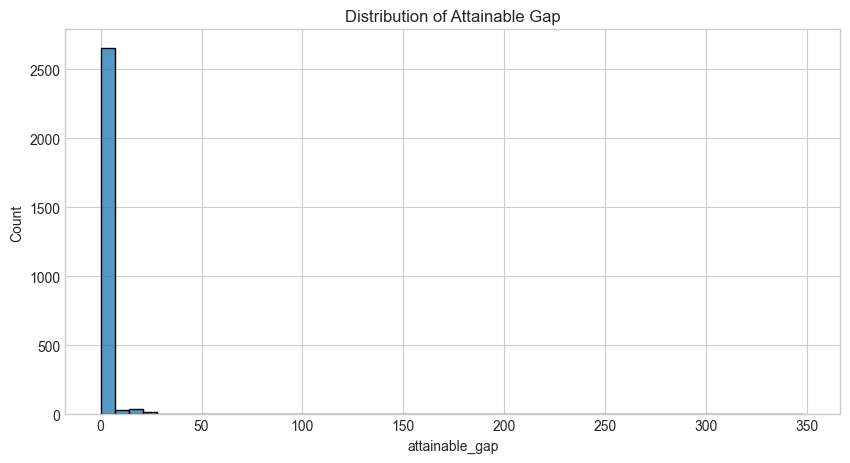

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["attainable_gap"], bins=50)
plt.title("Distribution of Attainable Gap")
plt.xlabel("attainable_gap")
plt.ylabel("Count")
plt.show()

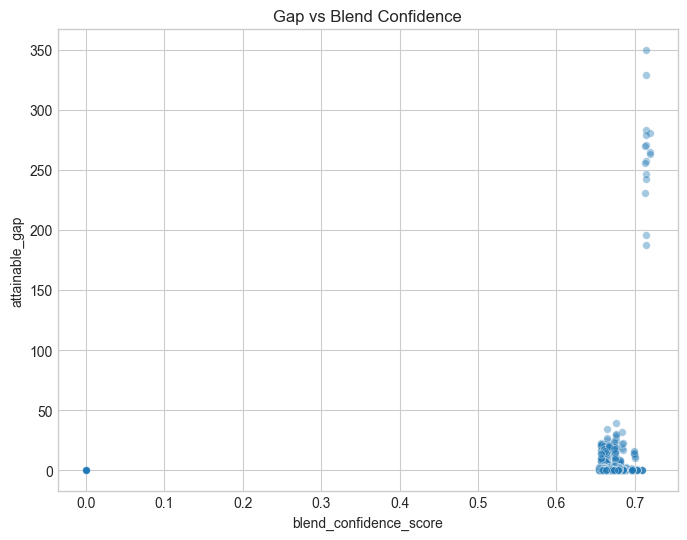

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="blend_confidence_score",
    y="attainable_gap",
    alpha=0.4,
    s=30
)
plt.title("Gap vs Blend Confidence")
plt.xlabel("blend_confidence_score")
plt.ylabel("attainable_gap")
plt.show()

In [8]:
top_skus = sku_summary.head(10)["Номенклатура"].tolist()
top_skus

['Пакет спасибо',
 'Киш грибы курица',
 'Пирожок зеленый лук',
 'Пакет звезды',
 'Тесто дрожжевое',
 'Конвертик курица',
 'Пирожок с горбушей',
 'Стакан 0,2',
 'Жар пицца с курицей',
 'Треугольник острый']

In [15]:
def plot_sku_timeseries(sku_name, data=df):
    sub = data[data["Номенклатура"] == sku_name].copy().sort_values("Дата")
    if sub.empty:
        print("No data for SKU:", sku_name)
        return

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(sub["Дата"], sub["sku_sales_total"], marker="o", label="Observed sales")
    ax.plot(sub["Дата"], sub["attainable_sales_baseline"], marker="s", linestyle="--", label="Attainable baseline")

    opp = sub[sub["opportunity_flag"] == True]
    if not opp.empty:
        ax.scatter(
            opp["Дата"],
            opp["attainable_sales_baseline"],
            color="red",
            s=80,
            label="Opportunity",
            zorder=5,
        )

    ax.set_title(sku_name)
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display_cols = [
        "Дата",
        "sku_sales_total",
        "attainable_sales_baseline",
        "attainable_gap",
        "share_source_primary",
        "blend_confidence_score",
        "good_execution_day",
        "early_stop_flag",
        "stockout_like_hours",
        "opportunity_type",
    ]
    # display(sub[display_cols].tail(20))

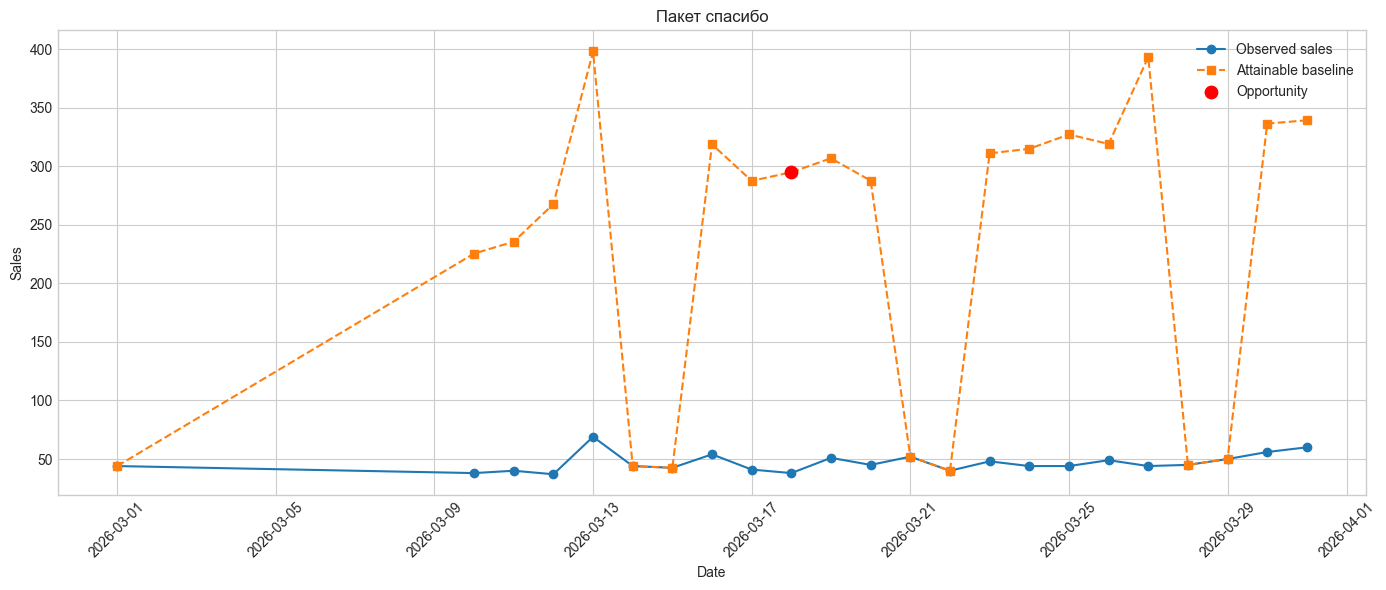

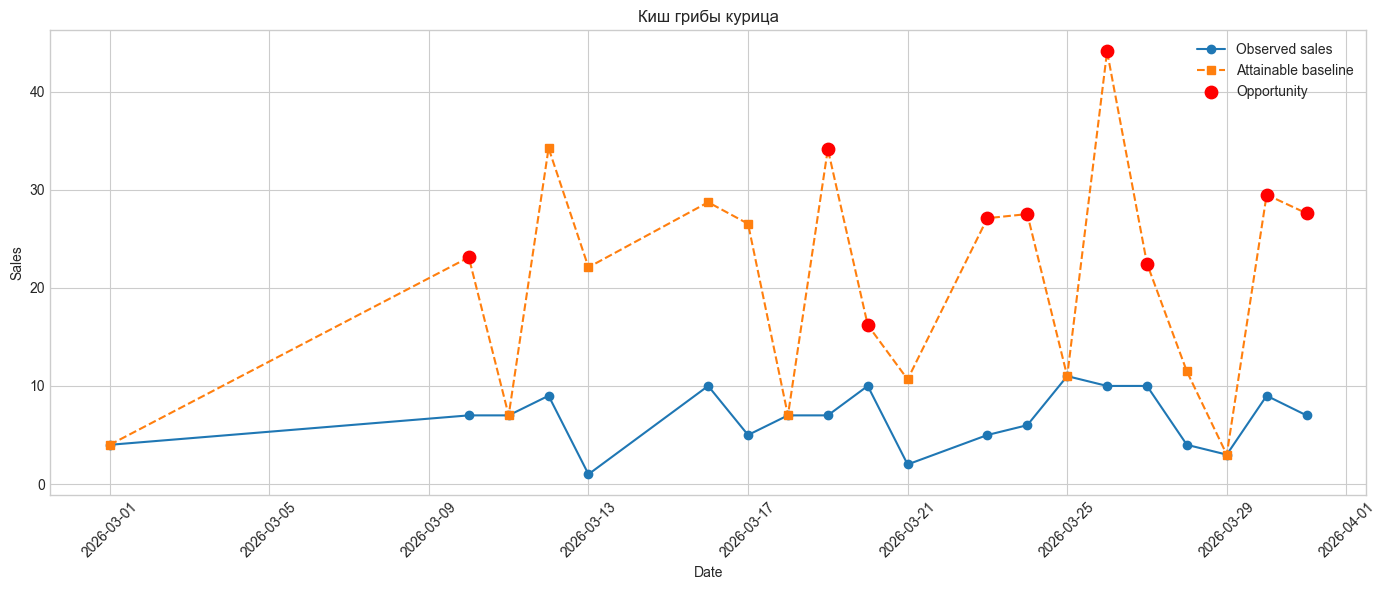

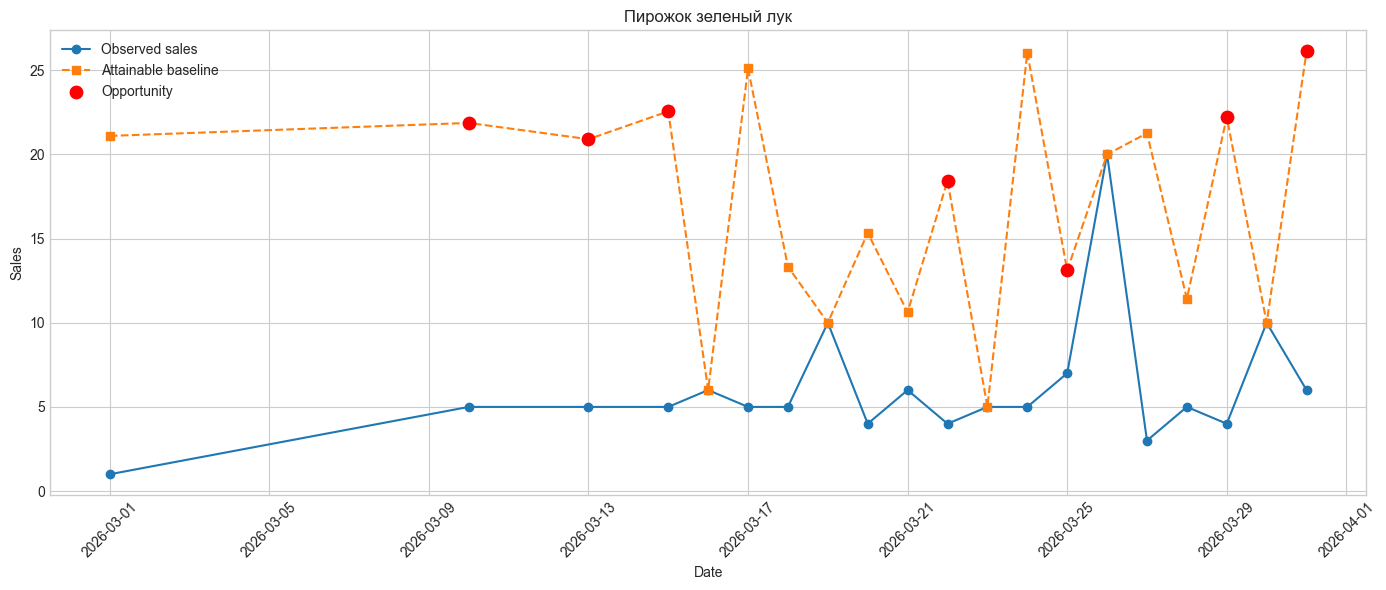

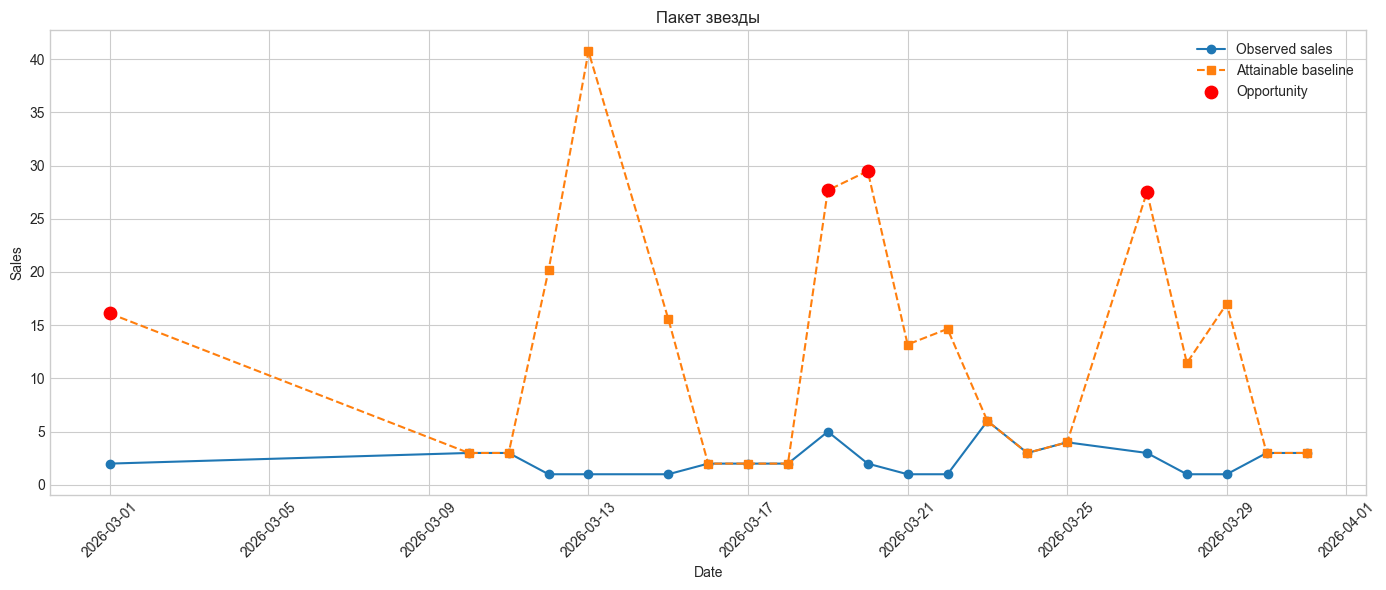

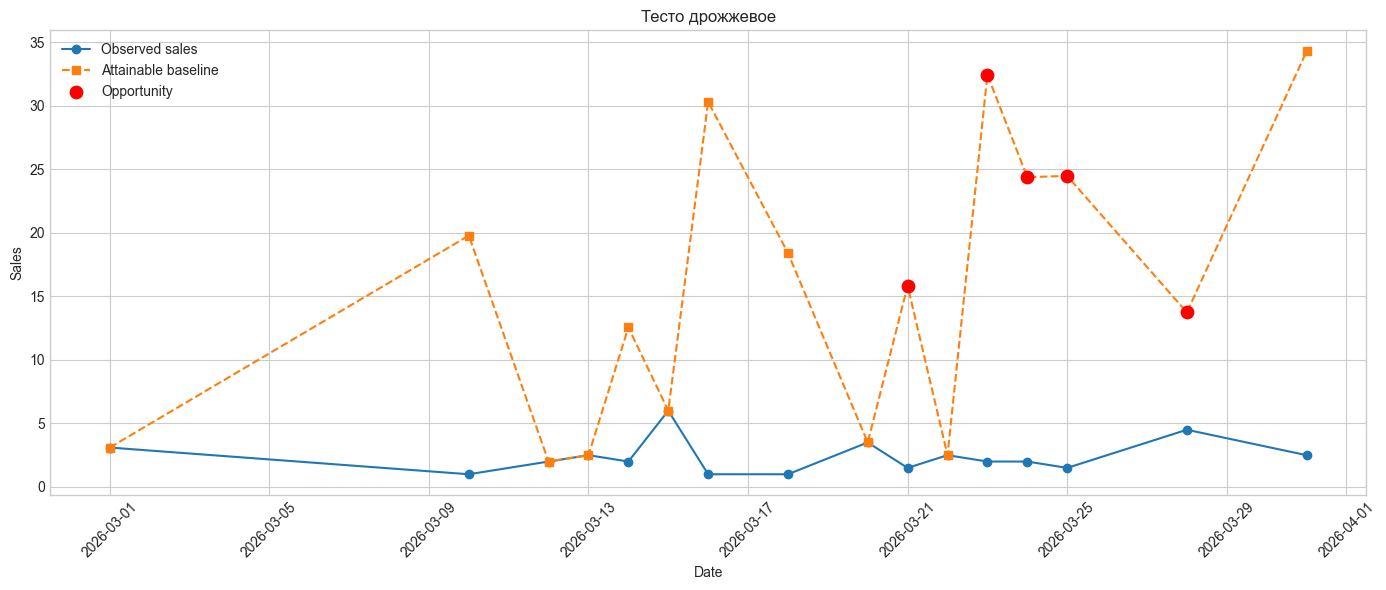

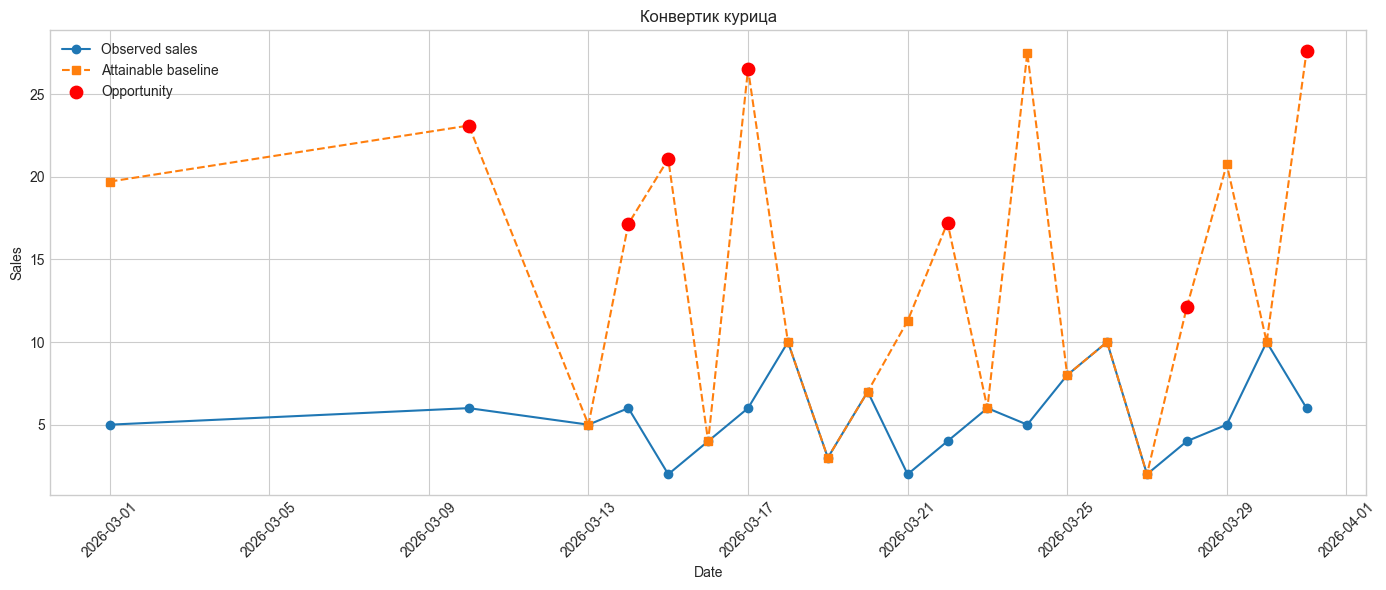

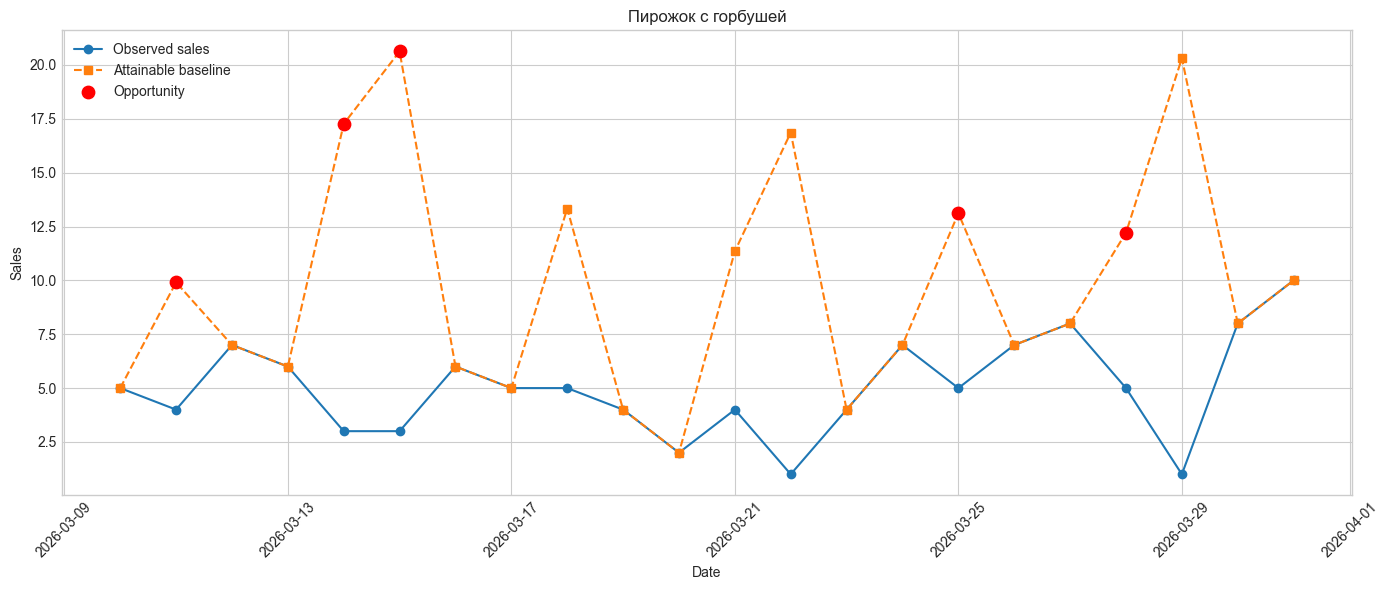

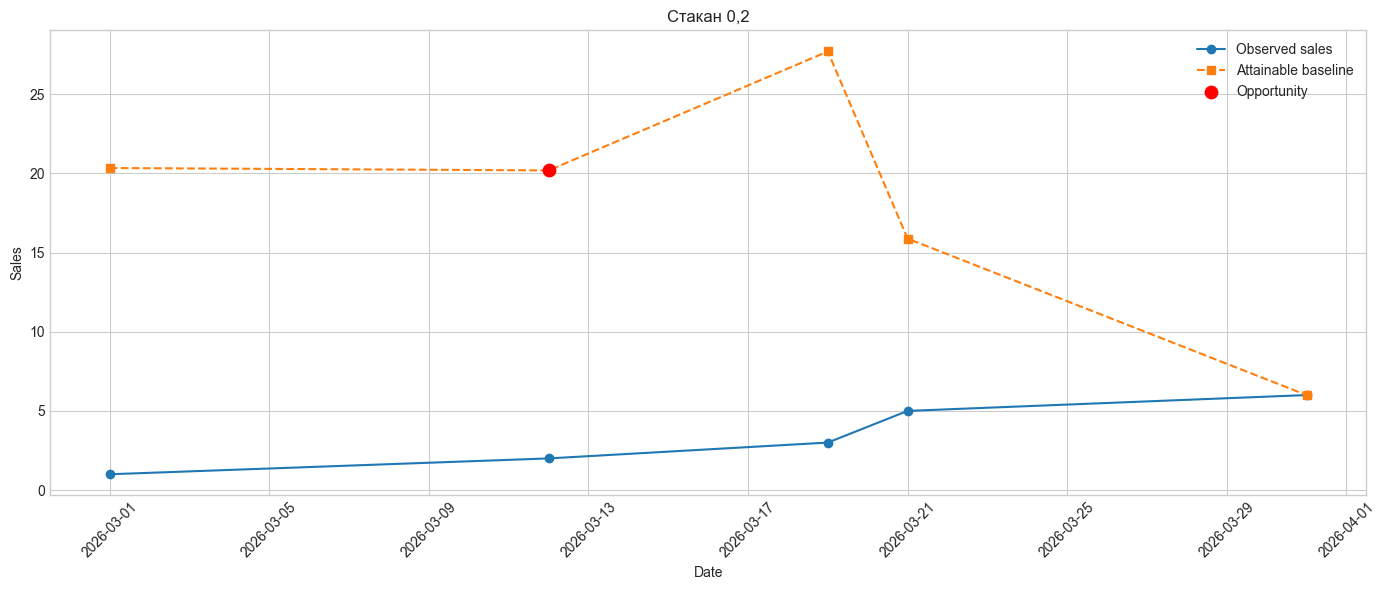

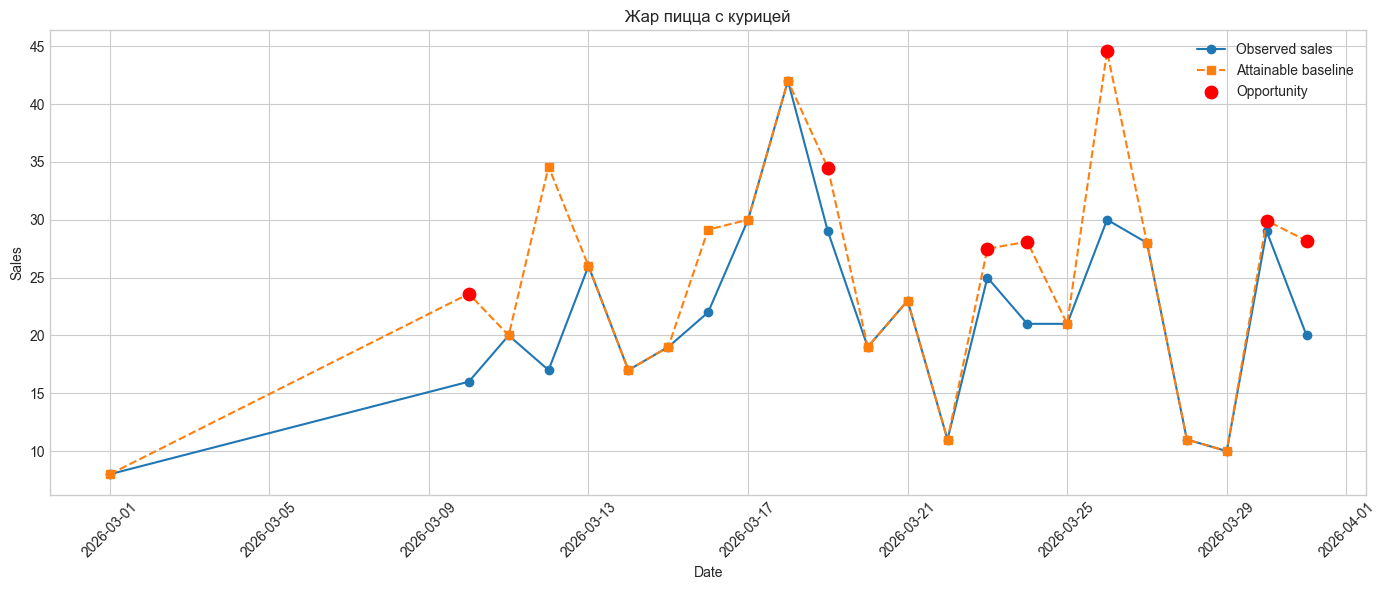

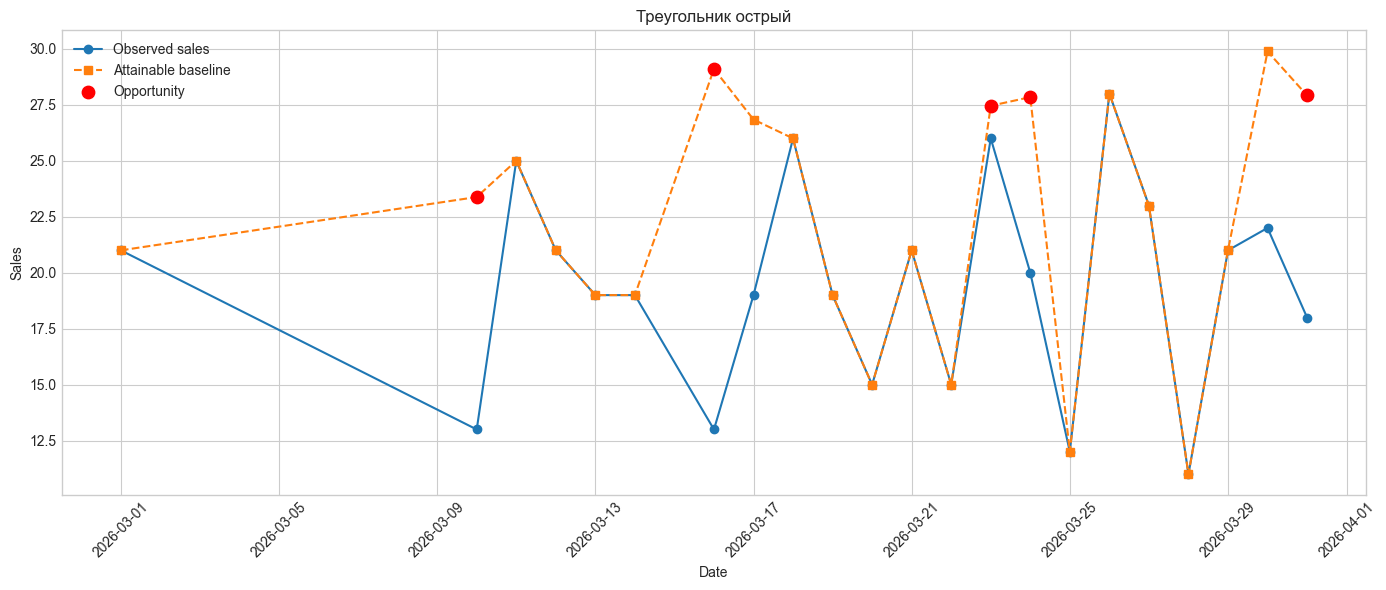

In [20]:
for sku in top_skus[:20]:
      plot_sku_timeseries(sku)

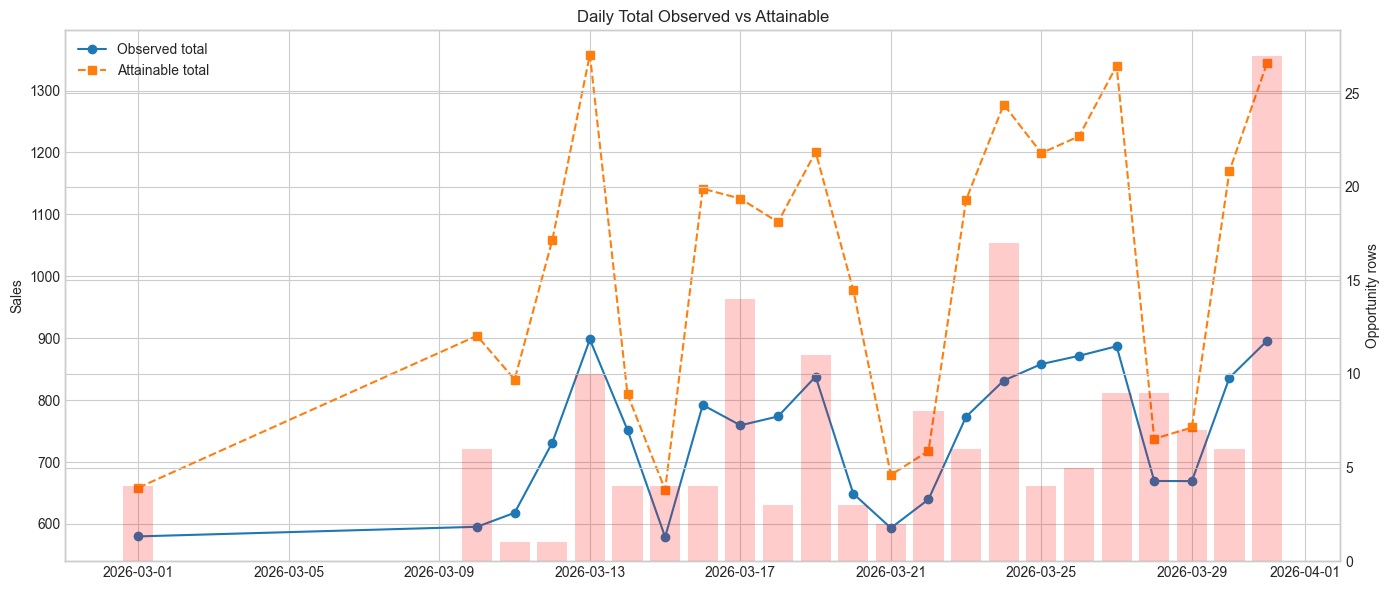

In [12]:
daily_summary = (
    df.groupby("Дата", as_index=False)
    .agg(
        observed_sales=("sku_sales_total", "sum"),
        attainable_sales=("attainable_sales_baseline", "sum"),
        total_gap=("attainable_gap", "sum"),
        opportunity_rows=("opportunity_flag", "sum"),
    )
)

daily_summary

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(daily_summary["Дата"], daily_summary["observed_sales"], marker="o", label="Observed total")
ax1.plot(daily_summary["Дата"], daily_summary["attainable_sales"], marker="s", linestyle="--", label="Attainable total")
ax1.set_ylabel("Sales")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.bar(daily_summary["Дата"], daily_summary["opportunity_rows"], alpha=0.2, color="red", label="Opportunity rows")
ax2.set_ylabel("Opportunity rows")

plt.title("Daily Total Observed vs Attainable")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

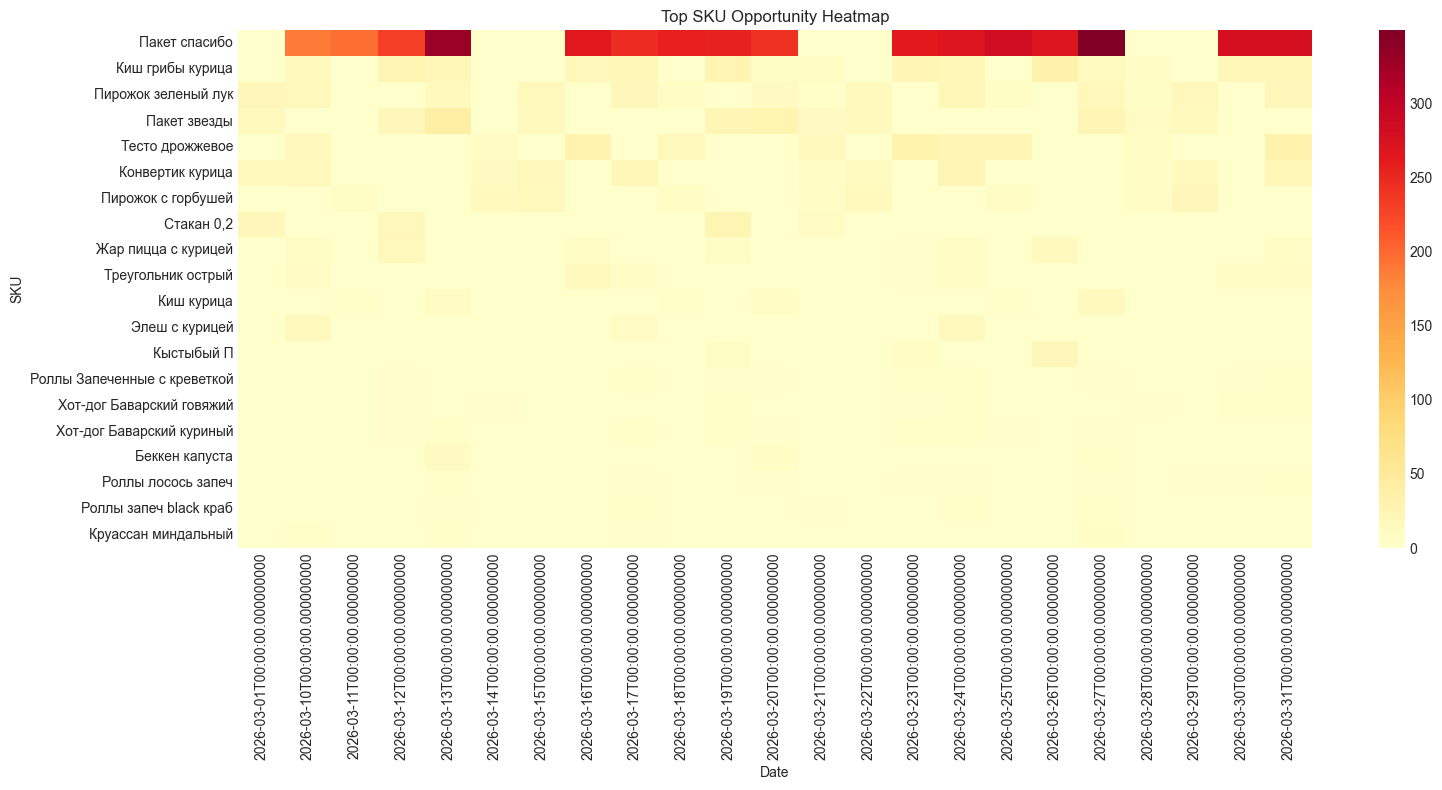

In [13]:
heat = df.pivot_table(
    index="Номенклатура",
    columns="Дата",
    values="attainable_gap",
    aggfunc="sum",
    fill_value=0,
)

top_heat = heat.loc[sku_summary.head(20)["Номенклатура"]]

plt.figure(figsize=(16, 8))
sns.heatmap(top_heat, cmap="YlOrRd")
plt.title("Top SKU Opportunity Heatmap")
plt.xlabel("Date")
plt.ylabel("SKU")
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

daily_base = pd.read_csv("C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/attainable_demand_baseline_p147_full.csv", encoding="utf-8-sig")
hourly_base = pd.read_csv("C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/hourly_positive_profile_daily_p147_hourpos_full.csv", encoding="utf-8-sig")

daily_base["Дата"] = pd.to_datetime(daily_base["Дата"])
hourly_base["Дата"] = pd.to_datetime(hourly_base["Дата"])

print(daily_base.shape, hourly_base.shape)

(27075, 31) (27075, 11)


In [23]:
cmp = daily_base.merge(
    hourly_base[
        ["Дата", "Пекарня", "Категория", "Номенклатура",
         "observed_sales", "expected_sales_from_hourly_profile", "total_hourly_gap"]
    ],
    on=["Дата", "Пекарня", "Категория", "Номенклатура"],
    how="inner",
    suffixes=("_daily_method", "_hourly_method")
)

cmp = cmp.rename(columns={
    "sku_sales_total": "observed_sales_daily",
    "attainable_sales_baseline": "attainable_daily_profile",
    "attainable_gap": "gap_daily_profile",
    "expected_sales_from_hourly_profile": "attainable_hourly_positive",
    "total_hourly_gap": "gap_hourly_positive",
})

print(cmp.shape)
cmp.head()

(27075, 34)


,Дата,Пекарня,Категория,Номенклатура,observed_sales_daily,bakery_sales_total,good_execution_day,availability_score,stockout_like_hours,zero_under_traffic_hours,early_stop_flag,Продано,ДеньНедели,bakery_sales_total_calc,category_sales_total,share_of_bakery,share_of_category,final_expected_share,share_source_primary,blend_confidence_score,share_bakery_sku,share_sku_global,share_bakery_category,share_category_global,attainable_sales_from_bakery,attainable_sales_from_category,attainable_daily_profile,gap_daily_profile,attainable_uplift_pct,opportunity_flag,opportunity_type,observed_sales,attainable_hourly_positive,gap_hourly_positive
0,2025-10-13,Проспект Победы 147 Казань,Маффин Печенье Донатс,M @ M Cookie,2.0,690.4,True,0.906667,2,4,False,NaN,NaN,690.4,7.0,0.002897,0.285714,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,2.0,0.0,0.0,False,none,2.0,2.000000,0.000000
1,2025-10-15,Проспект Победы 147 Казань,Маффин Печенье Донатс,M @ M Cookie,1.0,815.6,True,0.900000,1,6,False,NaN,NaN,815.6,11.0,0.001226,0.090909,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,False,none,1.0,1.028061,0.028061
2,2025-11-26,Проспект Победы 147 Казань,Маффин Печенье Донатс,M @ M Cookie,1.0,734.0,True,0.866667,2,7,False,NaN,NaN,734.0,10.0,0.001362,0.100000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,False,none,1.0,1.000000,0.000000
3,2025-11-27,Проспект Победы 147 Казань,Маффин Печенье Донатс,M @ M Cookie,5.0,861.7,False,0.812500,4,9,False,NaN,NaN,861.7,20.0,0.005802,0.250000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,5.0,0.0,0.0,False,none,5.0,5.000000,0.000000
4,2025-11-30,Проспект Победы 147 Казань,Маффин Печенье Донатс,M @ M Cookie,1.0,478.5,True,0.885714,2,5,False,NaN,NaN,478.5,18.0,0.002090,0.055556,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,False,none,1.0,1.000000,0.000000


In [24]:
sku_cmp = (
    cmp.groupby("Номенклатура", as_index=False)
    .agg(
        days=("Дата", "nunique"),
        observed_sales=("observed_sales_daily", "sum"),
        attainable_daily=("attainable_daily_profile", "sum"),
        attainable_hourly=("attainable_hourly_positive", "sum"),
        gap_daily=("gap_daily_profile", "sum"),
        gap_hourly=("gap_hourly_positive", "sum"),
    )
    .sort_values("gap_hourly", ascending=False)
)

sku_cmp.head(30)

,Номенклатура,days,observed_sales,attainable_daily,attainable_hourly,gap_daily,gap_hourly
226,Треугольник курица безд,236,11804.0,12482.348223,14870.290557,678.348223,3066.290557
225,Треугольник говядина безд,233,7197.0,7605.907408,9267.037365,408.907408,2070.037365
209,Сосиска в тесте,235,7543.0,7755.331928,9559.727501,212.331928,2016.727501
108,Кыстыбый П,233,6857.0,7329.527742,8646.317690,472.527742,1789.317690
167,Пицца с колбасой,236,6110.0,6663.778343,7788.351776,553.778343,1678.351776
210,Сосиска под шубой,236,5323.0,6337.864387,6862.499475,1014.864387,1539.499475
133,Пакет спасибо,230,7499.5,8833.456188,8977.749441,1333.956188,1478.249441
59,Жар пицца с курицей,236,5112.0,6346.419213,6583.109718,1234.419213,1471.109718
227,Треугольник острый,234,4145.0,6073.249980,5405.461713,1928.249980,1260.461713
263,Элеш с курицей,235,4047.0,6037.895094,5226.659849,1990.895094,1179.659849


In [29]:
def compare_sku(sku_name):
    sub = cmp[cmp["Номенклатура"] == sku_name].copy().sort_values("Дата")
    sub = sub.tail(30)  # Показываем только последние 30 дней для наглядности
    if sub.empty:
        print("No data")
        return

    plt.figure(figsize=(14, 6))
    plt.plot(sub["Дата"], sub["observed_sales_daily"], marker="o", label="Observed")
    plt.plot(sub["Дата"], sub["attainable_daily_profile"], marker="s", linestyle="--", label="Daily profile method")
    plt.plot(sub["Дата"], sub["attainable_hourly_positive"], marker="^", linestyle=":", label="Hourly positive method")
    plt.title(sku_name)
    plt.xlabel("Дата")
    plt.ylabel("Продажи")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # display(
    #     sub[
    #         [
    #             "Дата",
    #             "observed_sales_daily",
    #             "attainable_daily_profile",
    #             "attainable_hourly_positive",
    #             "gap_daily_profile",
    #             "gap_hourly_positive",
    #             "share_source_primary",
    #             "blend_confidence_score",
    #         ]
    #     ].tail(30)
    # )

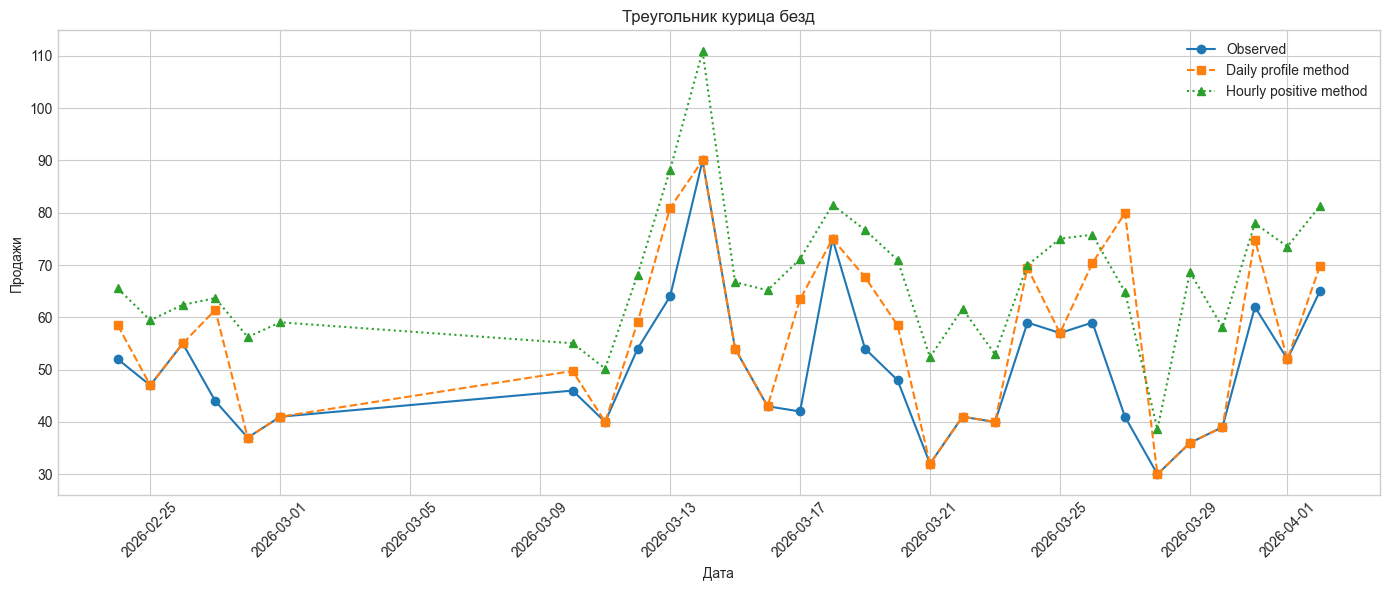

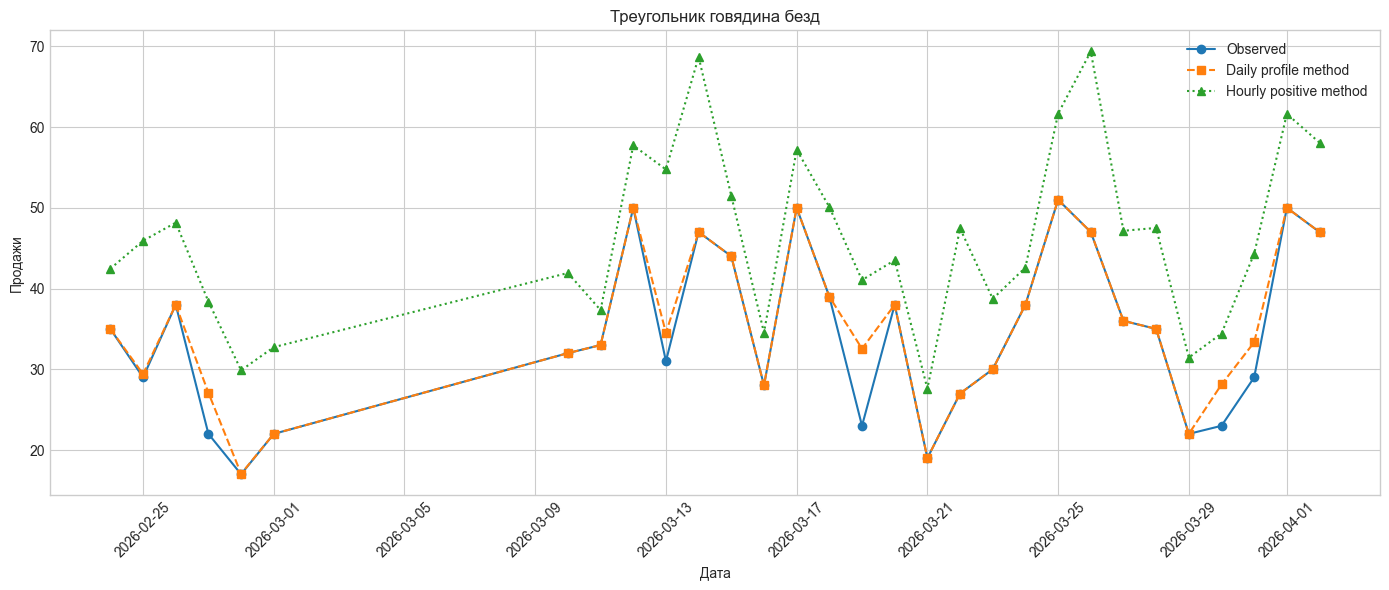

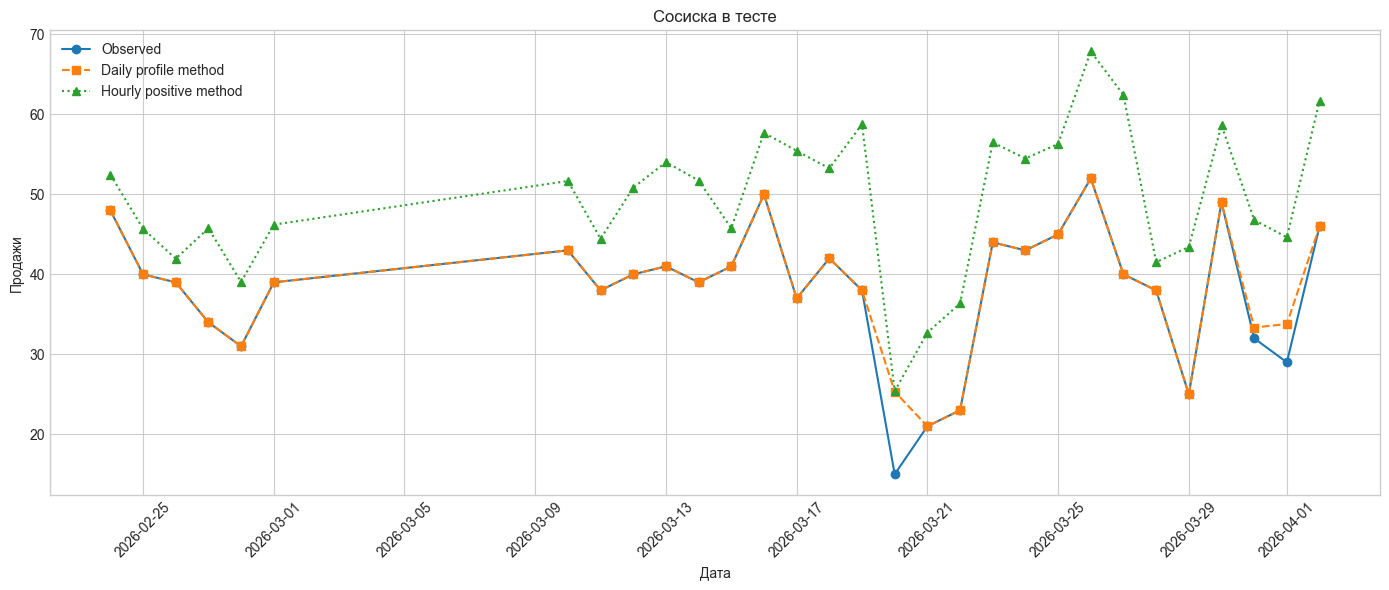

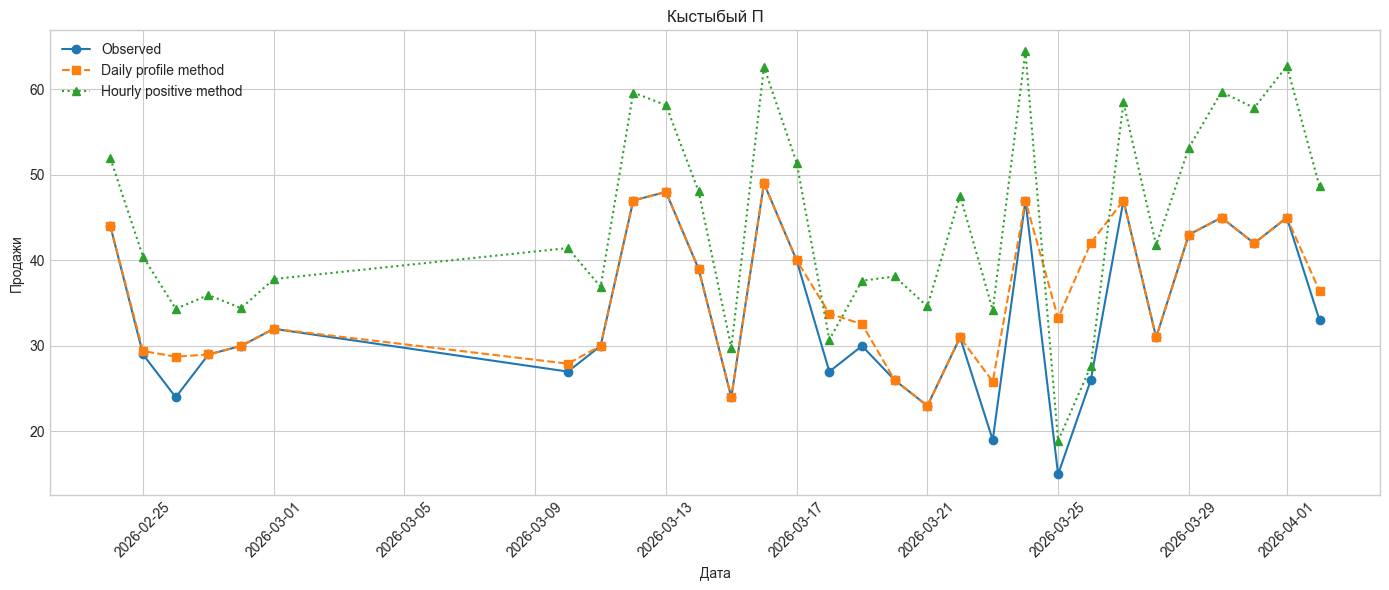

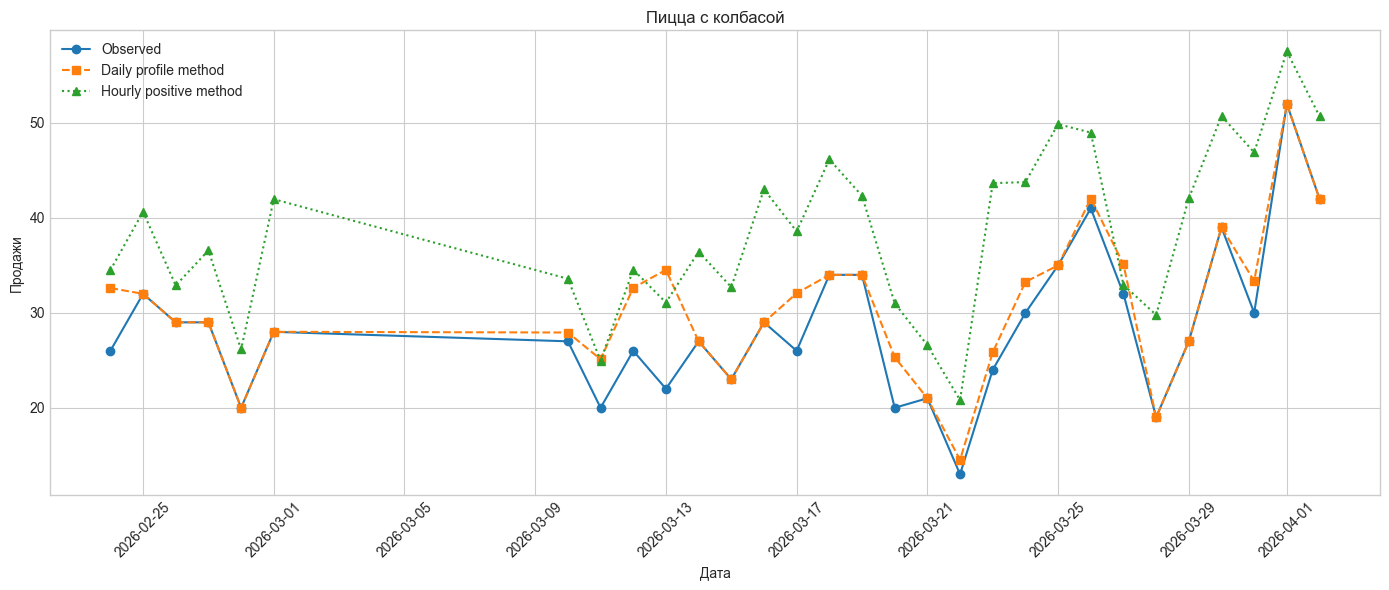

In [30]:
top_skus = sku_cmp.head(10)["Номенклатура"].tolist()
top_skus

for sku in top_skus[:5]:
    compare_sku(sku)

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

daily_base = pd.read_csv("C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/attainable_demand_baseline_p147_full.csv", encoding="utf-8-sig")
hourly_pos = pd.read_csv("C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/hourly_positive_profile_daily_p147_hourpos_full.csv", encoding="utf-8-sig")

daily_base["Дата"] = pd.to_datetime(daily_base["Дата"])
hourly_pos["Дата"] = pd.to_datetime(hourly_pos["Дата"])


cmp = daily_base.merge(
    hourly_pos[
        ["Дата", "Пекарня", "Категория", "Номенклатура",
         "observed_sales", "expected_sales_from_hourly_profile", "total_hourly_gap", "profiled_hours"]
    ],
    on=["Дата", "Пекарня", "Категория", "Номенклатура"],
    how="outer"
)

cmp["observed_sales_daily"] = cmp["sku_sales_total"].fillna(cmp["observed_sales"]).fillna(0)
cmp["attainable_daily_profile"] = cmp["attainable_sales_baseline"].fillna(cmp["observed_sales_daily"])
cmp["attainable_hourly_positive"] = cmp["expected_sales_from_hourly_profile"].fillna(cmp["observed_sales_daily"])
cmp["gap_daily_profile"] = cmp["attainable_gap"].fillna(0)
cmp["gap_hourly_positive"] = cmp["total_hourly_gap"].fillna(0)

cmp.shape

(64428, 40)

In [34]:
sku_cmp = (
    cmp.groupby("Номенклатура", as_index=False)
    .agg(
        days=("Дата", "nunique"),
        observed_sales=("observed_sales_daily", "sum"),
        attainable_daily=("attainable_daily_profile", "sum"),
        attainable_hourly=("attainable_hourly_positive", "sum"),
        gap_daily=("gap_daily_profile", "sum"),
        gap_hourly=("gap_hourly_positive", "sum"),
    )
    .sort_values("gap_hourly", ascending=False)
)

sku_cmp.head(30)

,Номенклатура,days,observed_sales,attainable_daily,attainable_hourly,gap_daily,gap_hourly
81,Картошка ассорти,236,806.0,872.576475,7493.374479,66.576475,6687.374479
108,Кыстыбый П,236,6857.0,7329.527742,13005.062542,472.527742,6148.062542
226,Треугольник курица безд,236,11804.0,12482.348223,17777.859084,678.348223,5973.859084
225,Треугольник говядина безд,236,7197.0,7605.907408,13149.290262,408.907408,5952.290262
227,Треугольник острый,236,4145.0,6073.249980,9908.043407,1928.249980,5763.043407
162,Пирожок капуста и курица,236,504.0,612.829016,6106.013868,108.829016,5602.013868
32,Графские развалины,236,475.0,563.369815,5991.862838,88.369815,5516.862838
21,Вак-бэлиш,236,2515.0,5170.076268,7998.568304,2655.076268,5483.568304
213,Сочень,236,2701.0,2723.497281,8153.985350,22.497281,5452.985350
165,Пирожок яблоко,236,1092.0,1114.985783,6519.973103,22.985783,5427.973103


In [37]:
def compare_sku(sku_name):
    sub = cmp[cmp["Номенклатура"] == sku_name].copy().sort_values("Дата")
    sub = sub.tail(30)  # Показываем только последние 30 дней для наглядности
    if sub.empty:
        print("No data")
        return

    plt.figure(figsize=(14, 6))
    plt.plot(sub["Дата"], sub["observed_sales_daily"], marker="o", label="Observed")
    plt.plot(sub["Дата"], sub["attainable_daily_profile"], linestyle="--", label="Daily profile")
    plt.plot(sub["Дата"], sub["attainable_hourly_positive"], linestyle=":", label="Hourly positive")
    plt.title(sku_name)
    plt.xlabel("Дата")
    plt.ylabel("Продажи")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # display(
    #     sub[[
    #         "Дата",
    #         "observed_sales_daily",
    #         "attainable_daily_profile",
    #         "attainable_hourly_positive",
    #         "gap_daily_profile",
    #         "gap_hourly_positive",
    #         "profiled_hours",
    #     ]].tail(30)
    # )

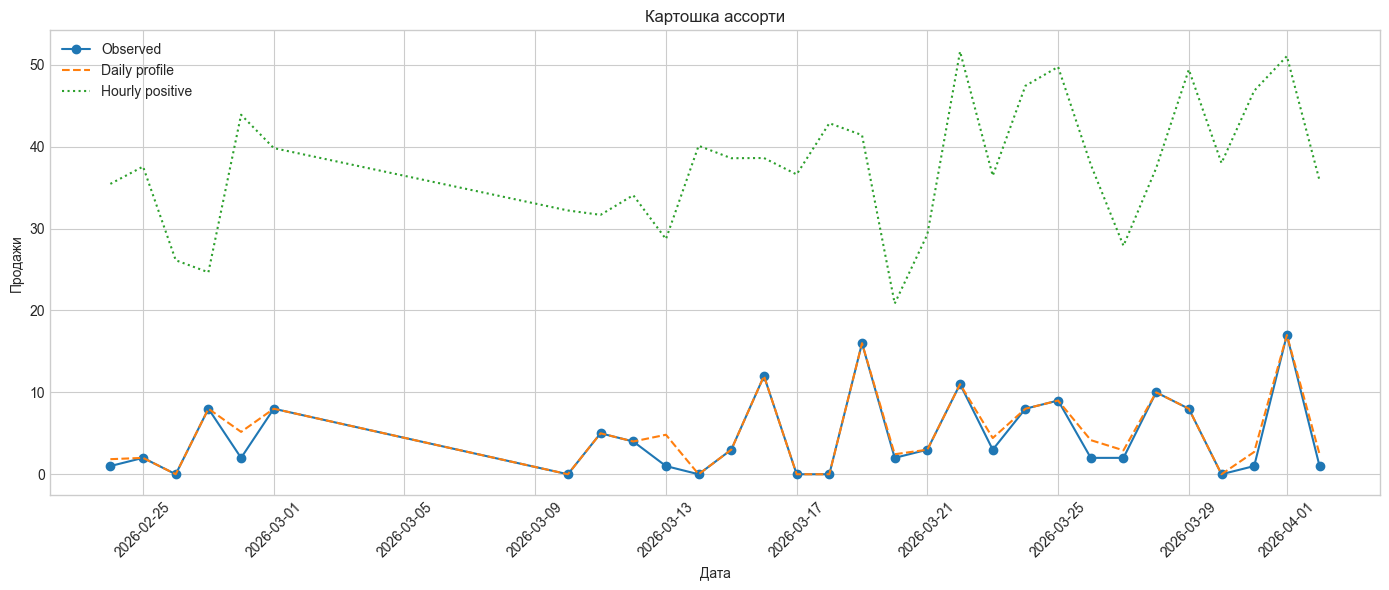

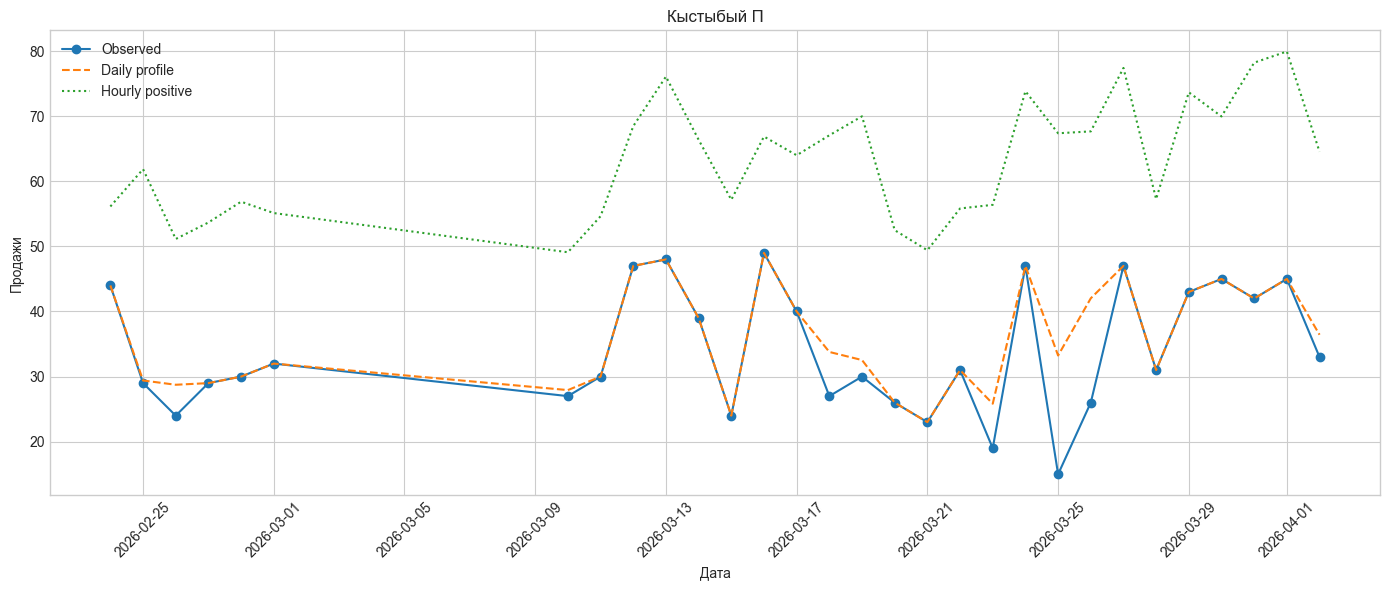

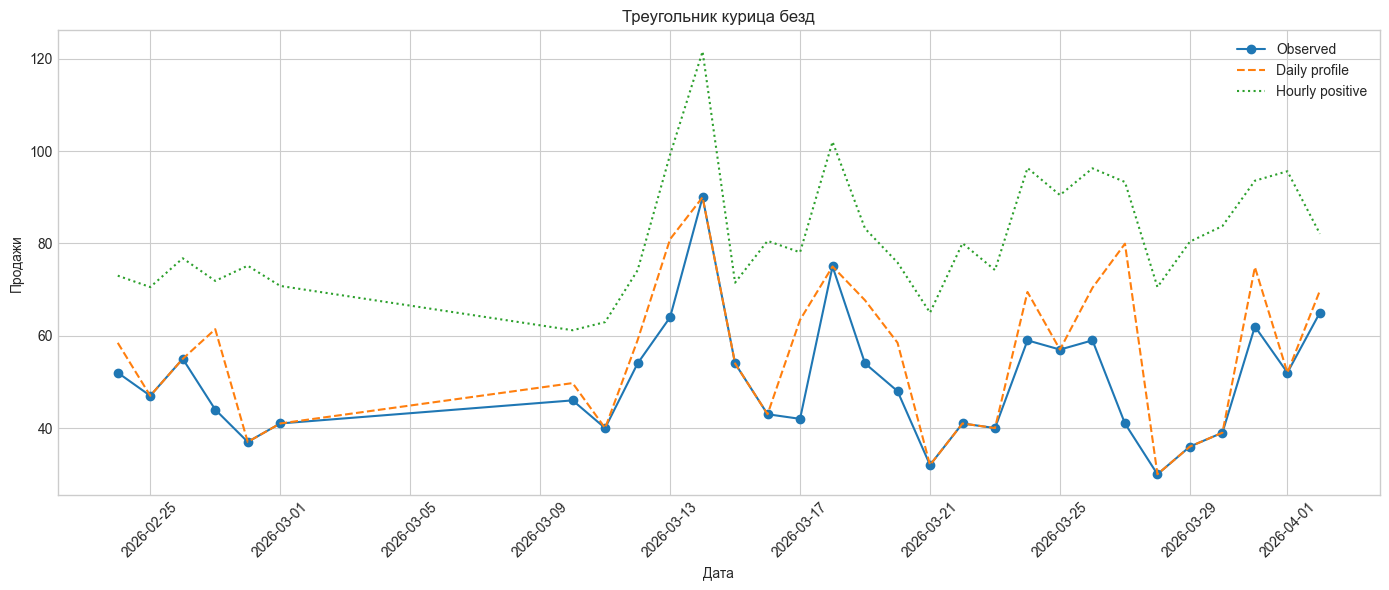

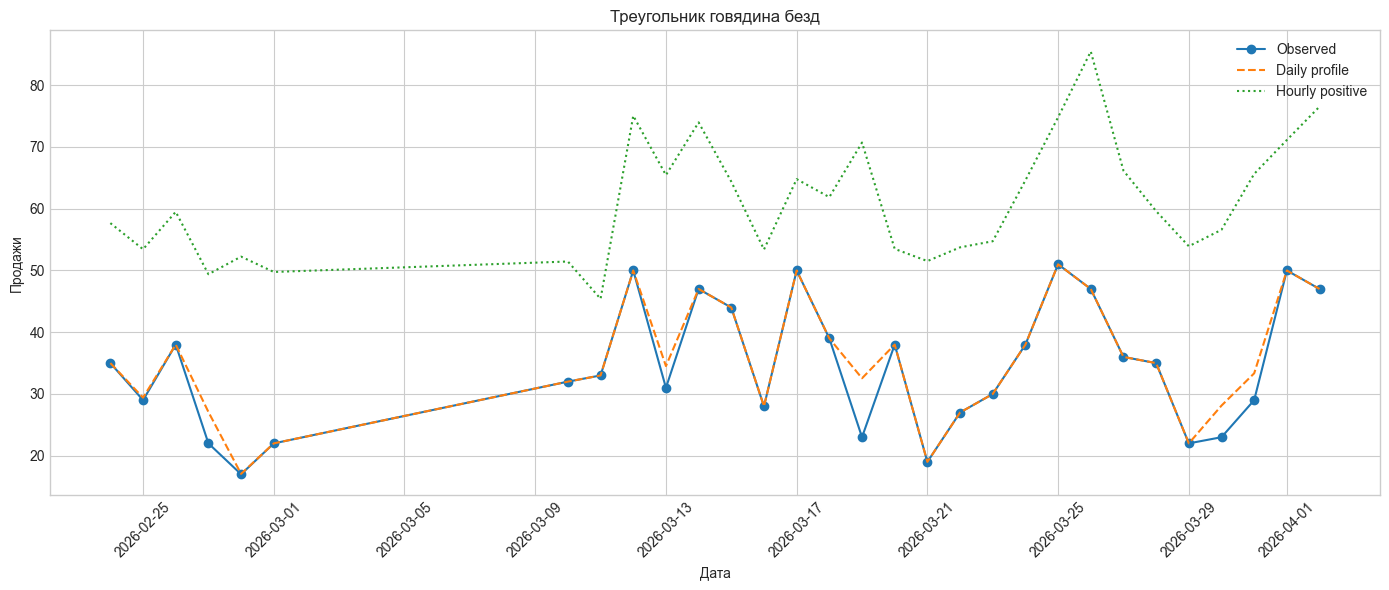

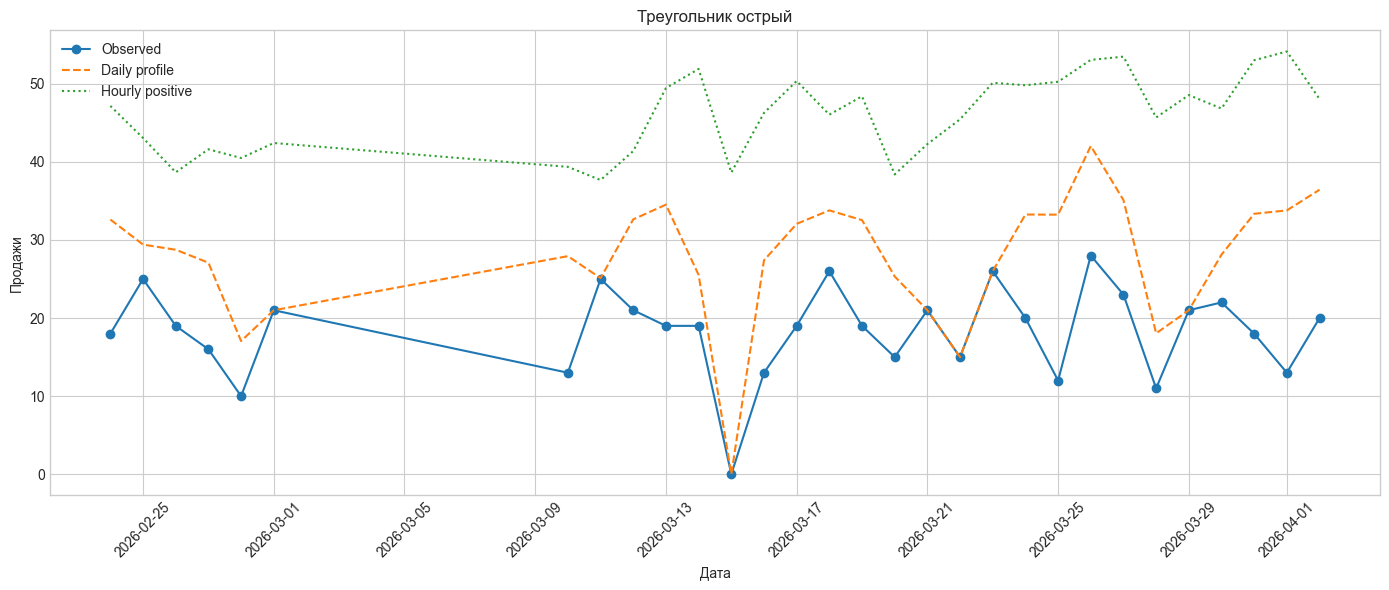

In [38]:
top_skus = sku_cmp.head(10)["Номенклатура"].tolist()
top_skus

for sku in top_skus[:5]:
    compare_sku(sku)